# preprocessing_tfidf_v2.ipynb

Features: GPS + TF-IDF/LSA 30 components  
Output → `data/processed_v8/`

In [1]:
import json, re
import pandas as pd
import numpy as np
import os, joblib
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD

BASE_DIR   = os.path.join(os.path.dirname(os.path.abspath('__file__')), '..')
INPUT_FILE = os.path.join(BASE_DIR, 'data', 'chotot_scraped.jsonl')
OUTPUT_DIR = os.path.join(BASE_DIR, 'data', 'processed_v8')
os.makedirs(OUTPUT_DIR, exist_ok=True)

records = []
with open(INPUT_FILE, encoding='utf-8') as f:
    for line in f:
        try: records.append(json.loads(line))
        except: pass

raw = pd.DataFrame(records)
print(f'Loaded: {raw.shape}')
print(raw.columns.tolist())

Loaded: (40896, 16)
['list_id', 'title', 'description', 'price_vnd', 'price_string', 'area_m2', 'latitude', 'longitude', 'ward', 'district', 'city', 'category_code', 'category_name', 'rooms', 'toilets', 'scraped_at']


## Cell 2 — Schema mapping & filter

In [2]:
df = pd.DataFrame()

df['list_id']      = raw['list_id']   # giữ để dedup theo ID
df['price_vnd']    = pd.to_numeric(raw['price_vnd'],  errors='coerce')
df['area_m2']      = pd.to_numeric(raw['area_m2'],    errors='coerce')
df['latitude']     = pd.to_numeric(raw['latitude'],   errors='coerce')
df['longitude']    = pd.to_numeric(raw['longitude'],  errors='coerce')
df['so_phong_ngu'] = pd.to_numeric(raw['rooms'],      errors='coerce')
df['so_phong_vs']  = pd.to_numeric(raw['toilets'],    errors='coerce')
df['title']        = raw['title'].fillna('')
df['description']  = raw['description'].fillna('')
df['ward']         = raw['ward'].fillna('')
df['district']     = raw['district'].fillna('')
df['city']         = raw['city'].fillna('')
df['category_name']= raw['category_name'].fillna('')

df = df[(df['price_vnd'] >= 100_000_000) & (df['price_vnd'] <= 500_000_000_000)]
df = df[(df['area_m2'] > 0) & (df['area_m2'] < 10000)]

# ── THAY ĐỔI CHÍNH ──
# v6 cũ: drop_duplicates(subset=['price_vnd','area_m2','district']) → xóa nhầm 24,998 listings
# v8 mới: dedup theo list_id (ID duy nhất từ API Chợ Tốt)
before = len(df)
df = df.drop_duplicates(subset=['list_id'])
df = df.drop(columns=['list_id'])   # không cần sau dedup
df = df.reset_index(drop=True)

print(f'Sau dedup list_id: {len(df):,} rows (bỏ {before - len(df):,} duplicate list_id)')
print(f'  So với v6 (15,898 rows): +{len(df) - 15898:,} rows thêm')
print(f'After filter: {df.shape}')

Sau dedup list_id: 40,896 rows (bỏ 0 duplicate list_id)
  So với v6 (15,898 rows): +24,998 rows thêm
After filter: (40896, 12)


## Cell 3 — Text Cleaning
Bỏ: giá tiền (leakage), SĐT, emoji, ký tự đặc biệt. Giữ: từ tiếng Việt có dấu.

In [3]:
PRICE_PATTERN = r'\d+[\.,]?\d*\s*(tỷ|triệu|tr\.?|ty|billion)'
PHONE_PATTERN = r'\*+|\b\d{9,11}\b'
KEEP_PATTERN  = r'[^a-zàáảãạăắằẳẵặâấầẩẫậđèéẻẽẹêếềểễệìíỉĩịòóỏõọôốồổỗộơớờởỡợùúủũụưứừửữựỳýỷỹỵ\s]'

def clean_text(text):
    text = str(text).lower()
    text = re.sub(PRICE_PATTERN, ' ', text)
    text = re.sub(PHONE_PATTERN, ' ', text)
    text = re.sub(KEEP_PATTERN,  ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['text_clean'] = (df['title'] + ' ' + df['description']).apply(clean_text)

print('Sample trước/sau clean:')
for i in range(3):
    raw_t   = (df['title'].iloc[i] + ' ' + df['description'].iloc[i])[:120]
    clean_t = df['text_clean'].iloc[i][:120]
    print(f'  Raw:   {raw_t}')
    print(f'  Clean: {clean_t}')
    print()

print(f'Avg words sau clean: {df["text_clean"].str.split().str.len().mean():.0f}')

Sample trước/sau clean:
  Raw:   HOT HOT -  Nhà cách  HXH  1  căn gần Gigamall – giáp Bình Thạnh Dự án: 
Thông tin chi tiết: HOT HOT -  Nhà cách  HXH  1 
  Clean: hot hot nhà cách hxh căn gần gigamall giáp bình thạnh dự án thông tin chi tiết hot hot nhà cách hxh căn gần gigamall giá

  Raw:   Bán gấp nhà mặt tiền nguyễn oanh 5×19m chính chủ giá mềm 🔥 SIÊU PHẨM MẶT TIỀN NGUYỄN OANH – VỊ TRÍ VÀNG KINH DOANH ĐỈNH 
  Clean: bán gấp nhà mặt tiền nguyễn oanh m chính chủ giá mềm siêu phẩm mặt tiền nguyễn oanh vị trí vàng kinh doanh đỉnh nhà mặt 

  Raw:   Nhà 4 Tấm Căn Đôi Nhà riêng tọa lạc tại Đường 31, Phường 10, Quận 6, Hồ Chí Minh, có diện tích 128m2 với mặt tiền rộng 8
  Clean: nhà tấm căn đôi nhà riêng tọa lạc tại đường phường quận hồ chí minh có diện tích m với mặt tiền rộng m có thang máy phù 

Avg words sau clean: 100


## Cell 4 — GPS features

In [4]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1); dlam = np.radians(lon2 - lon1)
    a = np.sin(dphi/2)**2 + np.cos(phi1)*np.cos(phi2)*np.sin(dlam/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

CITY_CENTERS = {
    'hcm': (10.7769, 106.7009), 'hn': (21.0285, 105.8048),
    'dn':  (16.0544, 108.2022), 'bd': (11.1535, 106.6543),
}
for ck, (clat, clon) in CITY_CENTERS.items():
    df[f'dist_{ck}_km'] = haversine(df['latitude'].values, df['longitude'].values, clat, clon)
dist_cols = [f'dist_{k}_km' for k in CITY_CENTERS]
df['dist_nearest_center_km'] = df[dist_cols].min(axis=1)

for col in ['latitude', 'longitude'] + dist_cols + ['dist_nearest_center_km']:
    if df[col].isna().any():
        dm = df.groupby('district')[col].transform('median')
        df[col] = df[col].fillna(dm).fillna(df[col].median())

print('GPS features OK')

GPS features OK


## Cell 5 — BDS type & keyword flags

In [5]:
CAT_MAP = {'Nhà ở': 'nha_o', 'Căn hộ/Chung cư': 'can_ho',
           'Đất': 'dat_nen', 'Văn phòng, Mặt bằng kinh doanh': 'van_phong'}
df['bds_type'] = df['category_name'].map(CAT_MAP).fillna('khac')

df['title_len'] = df['title'].str.len()
df['desc_len']  = df['description'].str.len()

KEYWORDS = {
    'kw_mat_tien':   r'mặt tiền|mặt phố',
    'kw_hem_xe_hoi': r'hẻm xe hơi|hẻm ô tô',
    'kw_full_nt':    r'full nội thất|đầy đủ nội thất',
    'kw_so_hong':    r'sổ hồng|sổ đỏ|đã có sổ',
    'kw_view_song':  r'view sông|nhìn sông',
    'kw_view_ho':    r'view hồ|nhìn hồ',
    'kw_penthouse':  r'penthouse',
    'kw_biet_thu':   r'biệt thự|villa',
    'kw_chinh_chu':  r'chính chủ',
    'kw_can_ban_gap':r'cần bán gấp|bán gấp',
}
text_raw = (df['title'] + ' ' + df['description']).str.lower()
for kw, pattern in KEYWORDS.items():
    df[kw] = text_raw.str.contains(pattern, regex=True, na=False).astype(int)

print('Category breakdown:')
print(df['bds_type'].value_counts())

Category breakdown:
bds_type
nha_o        18644
dat_nen      13371
can_ho        8181
van_phong      700
Name: count, dtype: int64


## Cell 6 — Train/Val/Test split

In [6]:
from sklearn.model_selection import train_test_split

df['log_price'] = np.log1p(df['price_vnd'])

train, temp = train_test_split(df, test_size=0.30, random_state=42)
val,   test = train_test_split(temp, test_size=0.50, random_state=42)

print(f'train: {len(train):,}  val: {len(val):,}  test: {len(test):,}')
print(f'Total: {len(train)+len(val)+len(test):,}  (v6 cũ: 15,898)')

train: 28,627  val: 6,134  test: 6,135
Total: 40,896  (v6 cũ: 15,898)


## Cell 7 — TF-IDF + LSA
**Fit trên train only** → transform val/test. Tránh leakage vocab.

Với data lớn hơn (~40k): vocab phong phú hơn, LSA bắt được pattern tốt hơn.

TF-IDF matrix (train): (28627, 15000)
Vocab size: 15,000

LSA explained variance:
   5 components: 3.1%
  10 components: 5.0%
  20 components: 7.5%
  30 components: 9.4%

Top 8 terms per LSA component (5 đầu tiên):
  C0: ['nhà', 'bán', 'đất', 'giá', 'đường', 'khu', 'cư', 'thông']
  C1: ['đất', 'thổ', 'thổ cư', 'đường', 'lô', 'lô đất', 'bán đất', 'mặt tiền']
  C2: ['hẻm', 'lầu', 'nhà', 'bán nhà', 'ệt', 'xe hơi', 'ệt lầu', 'hẻm xe']
  C3: ['án thông', 'dự án', 'án', 'dự', 'tin chi', 'chi tiết', 'tiết', 'chi']
  C4: ['tin chi', 'án thông', 'án', 'dự án', 'dự', 'chi tiết', 'tiết', 'thông tin']


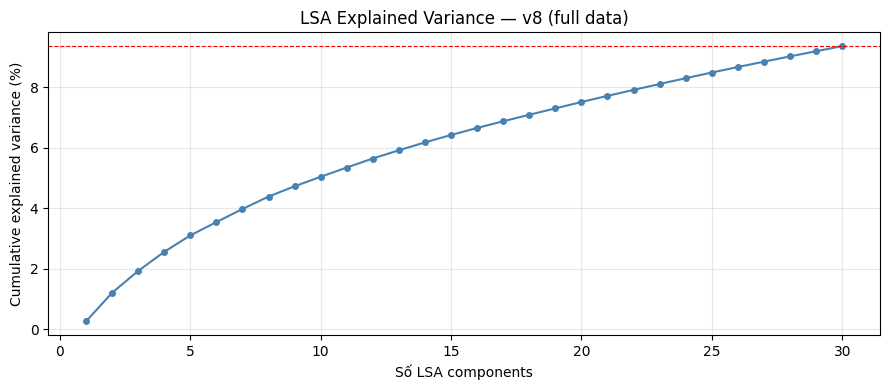

In [7]:
N_LSA = 30

tfidf = TfidfVectorizer(
    max_features  = 15_000,
    ngram_range   = (1, 2),
    min_df        = 5,
    sublinear_tf  = True,
    analyzer      = 'word',
    strip_accents = None,
)
X_tfidf_train = tfidf.fit_transform(train['text_clean'])
print(f'TF-IDF matrix (train): {X_tfidf_train.shape}')
print(f'Vocab size: {len(tfidf.vocabulary_):,}')

svd = TruncatedSVD(n_components=N_LSA, random_state=42)
X_lsa_train = svd.fit_transform(X_tfidf_train)

explained = svd.explained_variance_ratio_.cumsum()
print(f'\nLSA explained variance:')
for k in [5, 10, 20, 30]:
    print(f'  {k:2d} components: {explained[k-1]*100:.1f}%')

X_lsa_val  = svd.transform(tfidf.transform(val['text_clean']))
X_lsa_test = svd.transform(tfidf.transform(test['text_clean']))

lsa_cols = [f'lsa_{i}' for i in range(N_LSA)]
for split, X_lsa in [(train, X_lsa_train), (val, X_lsa_val), (test, X_lsa_test)]:
    for i, col in enumerate(lsa_cols):
        split[col] = X_lsa[:, i]

print('\nTop 8 terms per LSA component (5 đầu tiên):')
terms = np.array(tfidf.get_feature_names_out())
for ci in range(5):
    top_idx = svd.components_[ci].argsort()[-8:][::-1]
    print(f'  C{ci}: {list(terms[top_idx])}')

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(1, N_LSA+1), svd.explained_variance_ratio_.cumsum()*100,
        marker='o', markersize=4, color='steelblue')
ax.axhline(explained[-1]*100, color='red', linestyle='--', linewidth=0.8)
ax.set_xlabel('Số LSA components'); ax.set_ylabel('Cumulative explained variance (%)')
ax.set_title('LSA Explained Variance — v8 (full data)'); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## Cell 8 — Target Encoding (ward, district, loc_type)

In [8]:
SMOOTHING_K = 10

def fit_encoders(train_df, target_col='price_vnd'):
    enc = {}; global_mean = np.log1p(train_df[target_col]).mean()
    enc['global_mean'] = global_mean
    for col in ['city', 'district']:
        enc[f'{col}_te'] = {'map': np.log1p(train_df.groupby(col)[target_col].mean()).to_dict(),
                            'global_mean': global_mean}
    dist_log = np.log1p(train_df.groupby('district')[target_col].mean()).to_dict()
    ws = train_df.groupby(['district','ward'])[target_col].agg(['mean','count'])
    wm = {}
    for (d, w), row in ws.iterrows():
        dl = dist_log.get(d, global_mean); wl = np.log1p(row['mean']); n = int(row['count'])
        wm[w] = (n*wl + SMOOTHING_K*dl) / (n + SMOOTHING_K)
    enc['ward_te'] = {'map': wm, 'dist_fallback': dist_log, 'global_mean': global_mean}
    dl2 = np.log1p(train_df.groupby('district')[target_col].mean()).to_dict()
    lts = train_df.groupby(['district','bds_type'])[target_col].agg(['mean','count'])
    ltm = {}
    for (d, b), row in lts.iterrows():
        dl = dl2.get(d, global_mean); wl = np.log1p(row['mean']); n = int(row['count'])
        ltm[(d, b)] = (n*wl + SMOOTHING_K*dl) / (n + SMOOTHING_K)
    enc['loc_type_te'] = {'map': ltm, 'dist_fallback': dl2, 'global_mean': global_mean}
    return enc

def apply_encoders(df, enc):
    df = df.copy(); gm = enc['global_mean']
    if 'loc_type_te' in enc:
        info = enc['loc_type_te']
        def _lt(row):
            k = (row['district'], row['bds_type'])
            if k in info['map']: return info['map'][k]
            if row['district'] in info['dist_fallback']: return info['dist_fallback'][row['district']]
            return info['global_mean']
        df['loc_type_te'] = df[['district','bds_type']].apply(_lt, axis=1)
    if 'ward_te' in enc:
        info = enc['ward_te']
        def _wt(row):
            w = row.get('ward')
            if pd.notna(w) and w in info['map']: return info['map'][w]
            d = row.get('district')
            if pd.notna(d) and d in info['dist_fallback']: return info['dist_fallback'][d]
            return info['global_mean']
        df['ward_te'] = df[['ward','district']].apply(_wt, axis=1)
        df = df.drop(columns=['ward'])
    for col in ['city', 'district']:
        key = f'{col}_te'
        if key in enc and col in df.columns:
            info = enc[key]
            df[key] = df[col].map(info['map']).fillna(info['global_mean'])
            df = df.drop(columns=[col])
    if 'bds_type' in df.columns:
        for v in ['nha_o','can_ho','dat_nen','van_phong']:
            df[f'bds__{v}'] = (df['bds_type'] == v).astype(int)
        df = df.drop(columns=['bds_type'])
    return df

encoders = fit_encoders(train.copy())
for sn in ['train', 'val', 'test']:
    locals()[sn] = apply_encoders(locals()[sn], encoders)

print(f'train after encoding: {train.shape}')
print('TE cols:', [c for c in train.columns if c.endswith('_te')])

train after encoding: (28627, 66)
TE cols: ['loc_type_te', 'ward_te', 'city_te', 'district_te']


## Cell 9 — Interaction features + Scale

In [9]:
for split in [train, val, test]:
    split['log_area']       = np.log1p(split['area_m2'])
    split['loc_area_inter'] = split['district_te'] * split['area_m2']
    split['area_per_room']  = split['area_m2'] / split['so_phong_ngu'].clip(lower=1)

lsa_cols = [f'lsa_{i}' for i in range(30)]
SCALE_COLS = [c for c in [
    'area_m2', 'so_phong_ngu', 'so_phong_vs', 'title_len', 'desc_len',
    'latitude', 'longitude',
    'dist_hcm_km', 'dist_hn_km', 'dist_dn_km', 'dist_bd_km', 'dist_nearest_center_km',
    'log_area', 'loc_area_inter', 'area_per_room',
] + lsa_cols if c in train.columns]

scaler = RobustScaler()
scaler.fit(train[SCALE_COLS])
for split in [train, val, test]:
    split[SCALE_COLS] = scaler.transform(split[SCALE_COLS])

encoders['scaler']     = scaler
encoders['scale_cols'] = SCALE_COLS
encoders['tfidf']      = tfidf
encoders['svd']        = svd
encoders['n_lsa']      = 30

print(f'Scaled {len(SCALE_COLS)} columns')
print(f'Final train shape: {train.shape}')

Scaled 45 columns
Final train shape: (28627, 69)


## Cell 10 — Save processed_v8

In [10]:
DROP_FINAL = ['title', 'description', 'text_clean', 'category_name',
              'price_vnd', 'price_string', 'scraped_at', 'city_te']

FEATURE_COLS = [c for c in train.columns if c not in DROP_FINAL + ['log_price']]

for name, split in [('train', train), ('val', val), ('test', test)]:
    keep = [c for c in FEATURE_COLS + ['log_price'] if c in split.columns]
    split[keep].to_parquet(os.path.join(OUTPUT_DIR, f'{name}.parquet'), index=False)

artifacts = {
    'encoders':         encoders,
    'scale_cols':       SCALE_COLS,
    'feature_cols':     FEATURE_COLS,
    'tfidf':            tfidf,
    'svd':              svd,
    'n_lsa':            30,
    'gps_city_centers': CITY_CENTERS,
}
joblib.dump(artifacts, os.path.join(OUTPUT_DIR, 'preprocessing_artifacts.pkl'))

print(f'Saved to {OUTPUT_DIR}')
print(f'Total features: {len(FEATURE_COLS)}')
print(f'LSA features : {[c for c in FEATURE_COLS if c.startswith("lsa_")]}')
print(f'GPS features : {[c for c in FEATURE_COLS if "dist" in c or c in ["latitude","longitude"]]}')

Saved to /Users/nals_macbook_108/TTNT/house-price-prediction-chotot/notebooks/../data/processed_v8
Total features: 62
LSA features : ['lsa_0', 'lsa_1', 'lsa_2', 'lsa_3', 'lsa_4', 'lsa_5', 'lsa_6', 'lsa_7', 'lsa_8', 'lsa_9', 'lsa_10', 'lsa_11', 'lsa_12', 'lsa_13', 'lsa_14', 'lsa_15', 'lsa_16', 'lsa_17', 'lsa_18', 'lsa_19', 'lsa_20', 'lsa_21', 'lsa_22', 'lsa_23', 'lsa_24', 'lsa_25', 'lsa_26', 'lsa_27', 'lsa_28', 'lsa_29']
GPS features : ['latitude', 'longitude', 'dist_hcm_km', 'dist_hn_km', 'dist_dn_km', 'dist_bd_km', 'dist_nearest_center_km', 'district_te']


## Cell 11 — EDA LSA

In [28]:
# category breadkdown trong train
print()
print('Category breakdown trong train v8:')
for col in ['bds__nha_o','bds__can_ho','bds__dat_nen','bds__van_phong']:
    if col in train.columns:
        print(f'  {col}: {int(train[col].sum()):,}')


Category breakdown trong train v8:
  bds__nha_o: 12,935
  bds__can_ho: 5,760
  bds__dat_nen: 9,457
  bds__van_phong: 475


Top 10 LSA components tương quan nhất với log_price:
  lsa_4: +0.2819
  lsa_5: +0.2043
  lsa_6: +0.1985
  lsa_3: -0.1871
  lsa_9: +0.1620
  lsa_2: +0.1551
  lsa_14: -0.1523
  lsa_17: +0.1446
  lsa_26: +0.1446
  lsa_24: -0.1235


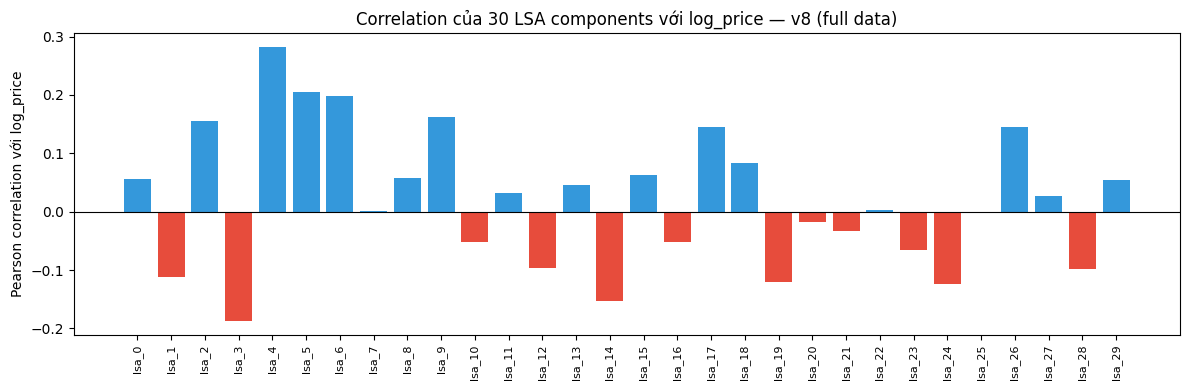

In [12]:
# Correlation LSA vs log_price
lsa_cols = [f'lsa_{i}' for i in range(30)]
corrs = train[[col for col in lsa_cols if col in train.columns] + ['log_price']].corr()['log_price'].drop('log_price')
corrs_sorted = corrs.abs().sort_values(ascending=False)

print('Top 10 LSA components tương quan nhất với log_price:')
for col in corrs_sorted.head(10).index:
    print(f'  {col}: {corrs[col]:+.4f}')

fig, ax = plt.subplots(figsize=(12, 4))
colors = ['#e74c3c' if v < 0 else '#3498db' for v in corrs.values]
ax.bar(range(len(corrs)), corrs.values, color=colors)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(range(len(corrs)))
ax.set_xticklabels([f'lsa_{i}' for i in range(len(corrs))], rotation=90, fontsize=8)
ax.set_ylabel('Pearson correlation với log_price')
ax.set_title('Correlation của 30 LSA components với log_price — v8 (full data)')
plt.tight_layout(); plt.show()